# Multiple Linear Regression

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import math
from myst_nb import glue
import seaborn as sns
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf


## Load data

The trees data set provides measurements of the girth, height, and volume of timber in 31 felled black cherry trees, also known as Prunus serotina. The height of the trees is given in feet (ft) and the volume is given in cubic feet (cft). The girth is the diameter of the tree (in inches) measured at 4 ft 6 in (approx. 1.37 m) above the ground.

We take a quick look at the data set by applying the head-method and immediately convert the variables in meters, respectively, cubic meters, by applying these equations

In [4]:
df_trees = sm.datasets.get_rdataset('trees').data

# 1 in = 0.0254 m, 1 ft = 0.3048 m, and 1 cft = 0.0283168 m^3.

df_trees['Girth'] = df_trees['Girth'] * 0.0254
df_trees['Height'] = df_trees['Height'] * 0.3048
df_trees['Volume'] = df_trees['Volume'] * 0.0283168
df = df_trees.round(3)
df.head()

column = list(df.columns.values.tolist())
feature_name = [str(x) for x in column[:]]

## Extract variables

In [5]:
y = df['Volume'].to_numpy()
x = sm.add_constant(df[['Girth', 'Height']].to_numpy())

## Visualize Multivariate Data

### Pairplot

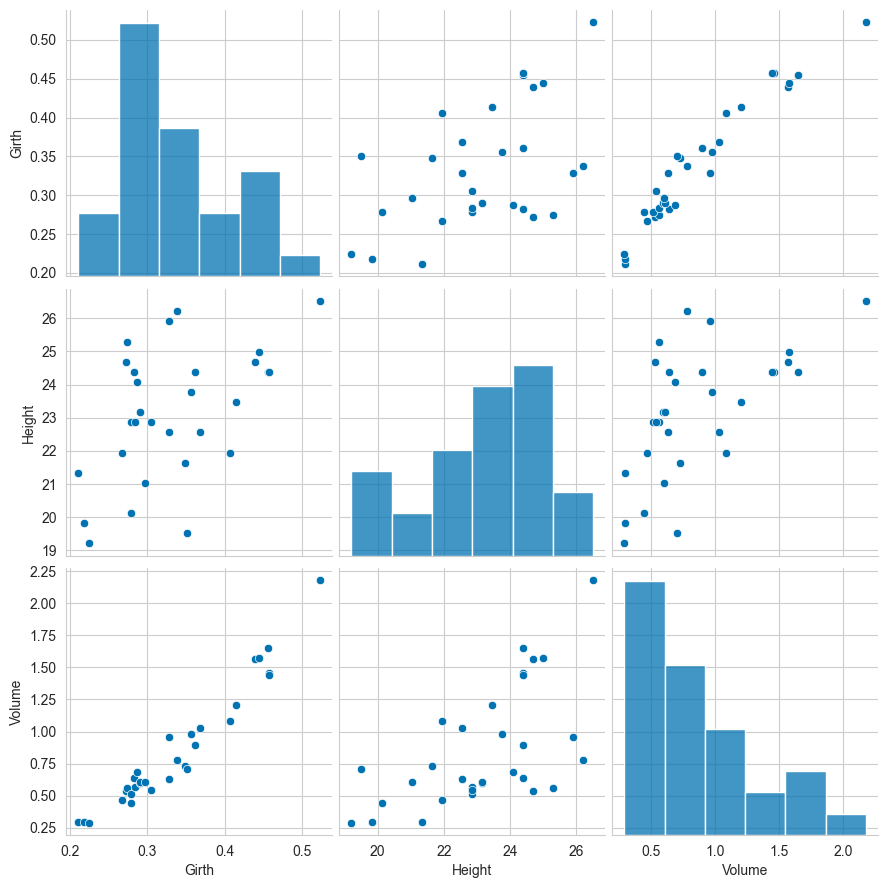

In [6]:
# Visualize the data using scatter plot and histogram
sns.set_palette('colorblind')
sns.pairplot(data=df, height=3)

### Histogram

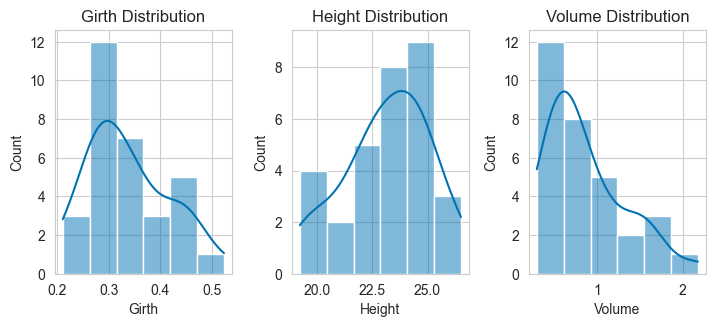

In [7]:
# Visualize the distribution of each feature using histograms.
plt.figure(figsize=(12, 12))
for i, feature in enumerate(feature_name):
    plt.subplot(4, 5, i+1)
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'{feature} Distribution')
plt.tight_layout()
plt.show()

### Correlation heatmaps

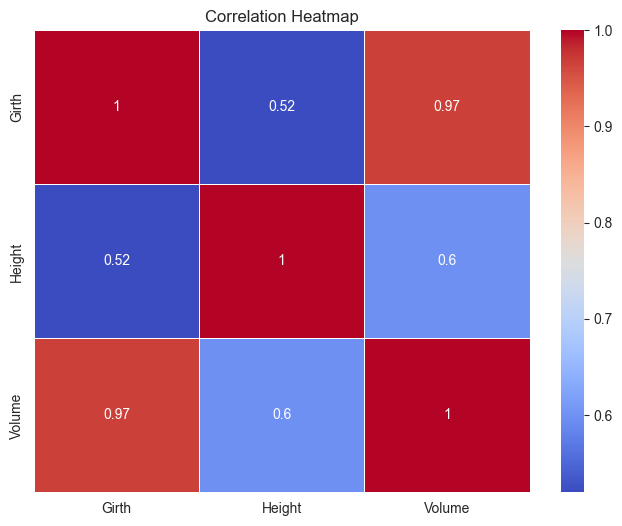

In [8]:
correlation_matrix = df.corr(numeric_only= True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Scatter Plot

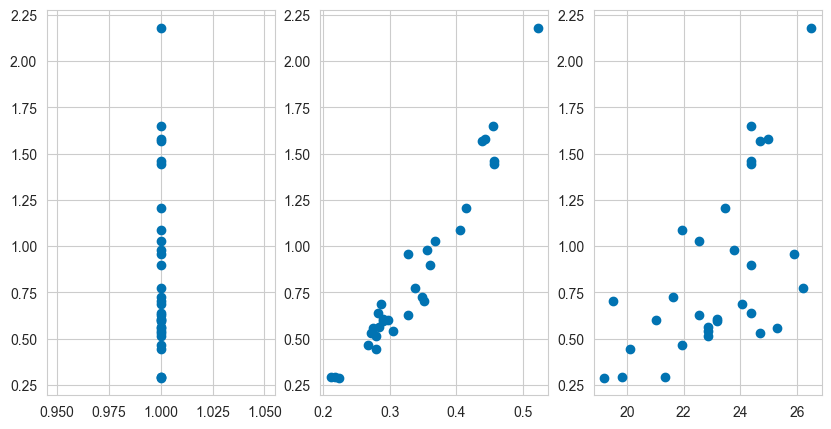

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10,5))
axs[0].plot(x[:,0], y, 'o')
axs[1].plot(x[:,1], y, 'o')
axs[2].plot(x[:,2], y, 'o')

## Construct model

### Beta coefficients

In [10]:
def find_coeffs (x, y):
    left = np.matmul(x.transpose(), x)
    right = np.matmul(x.transpose(), y)

    beta_coeffs = np.matmul(np.linalg.inv(left), right)
    
    #beta_coeffs = np.dot((np.linalg.inv(np.dot(x.T, x))), np.dot(x.T, y))
    
    #print(f'Intercept:\t{beta_coeffs[0]}, \nGirth:\t\t{beta_coeffs[1]}, \nHeight:\t\t{beta_coeffs[2]}')
    
    return beta_coeffs

In [11]:
beta = find_coeffs(x, y)
print(f"Equation: y = {beta[0]:.5f} + {beta[1]:.5f}x1 + {beta[2]:.5f}x2")

Equation: y = -1.64166 + 5.25283x1 + 0.03144x2


### Make prediction

In [12]:
def prediction(x, beta):
    pred = np.dot(x, beta)
    return pred

In [13]:
y_pred = prediction(x, beta)

## Model evaluation

In [14]:
# Calculating mean absolute error
mae_ = np.mean(np.abs(y_pred - y))

# Calculating root mean square error
mse_ = np.square(np.subtract(y, y_pred)).mean()
rmse_ = math.sqrt(mse_)

# Calculating r_square
SSE = np.sum(np.square((y - y_pred)))
y_mean = np.mean(y)
SST = np.sum(np.square(y - y_mean))
r2score_ = 1 - (SSE / SST)
adj_r2 = 1 - ((SSE/SST)*(((len(y)-1))/(len(y)-x.shape[1]-1)))
# Standard error prediction, RPD, Bias
sep_ = np.std(y_pred - y)
rpd_ = np.std(y)/sep_
bias_ = np.mean(y_pred - y)

print(f"Coefficient of determination (R^2): {r2score_:.2f}")
print(f"Adjusted R^2: {adj_r2:.4f}")
print(f"Mean absolute error (MAE): {mae_:.2f}")
print(f"Mean squared error (MSE): {mse_:.2f}")
print(f"Root mean squared error (RMSE): {rmse_:.2f}")
print(f"Standard error prediction: {sep_:.2f}")
print(f"RPD: {rpd_:.2f}")
print(f"Bias: {bias_:.2f}")

Coefficient of determination (R^2): 0.95
Adjusted R^2: 0.9418
Mean absolute error (MAE): 0.08
Mean squared error (MSE): 0.01
Root mean squared error (RMSE): 0.10
Standard error prediction: 0.10
RPD: 4.37
Bias: -0.00


## 3D Plot

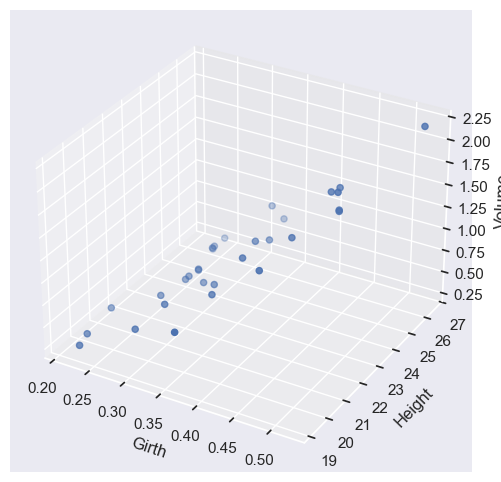

In [26]:
from mpl_toolkits.mplot3d import axes3d
sns.set(style='darkgrid')
X, Y, Z = axes3d.get_test_data(0.05)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(
    df['Girth'],
    df['Height'],
    df['Volume'],
)

ax.set_xlabel("Girth")
ax.set_ylabel("Height")
ax.set_zlabel("Volume")

plt.show()

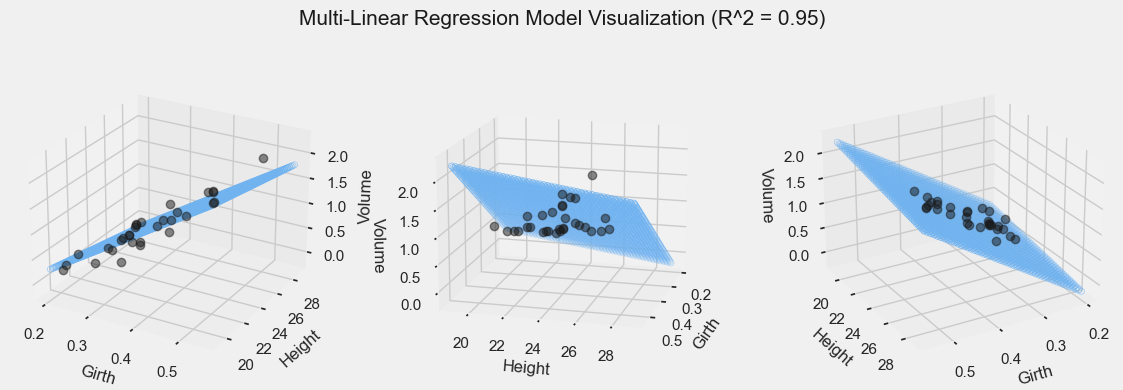

In [49]:
# Set independent and dependent variables
X_vis = df[['Girth', 'Height']]
y_vis = df['Volume']

# Initialize model from sklearn and fit it into our data
beta_vis = find_coeffs(X_vis, y_vis)

y_pred_vis = prediction(X_vis, beta_vis)

# Prepare data
X_ = df[['Girth', 'Height']].values.reshape(-1, 2)
Y_ = df['Volume']

# Create rage for each dimension
x_ = X_[:, 0]
y_ = X_[:, 1]
z_ = Y_

xx_pred = np.linspace(0.2, 0.55, 50)
yy_pred = np.linspace(19, 29, 50)
xx_pred, yy_pred = np.meshgrid(xx_pred, yy_pred)
model_vis = np.array([xx_pred.flatten(), yy_pred.flatten()]).T
predicted_vis = prediction(model_vis, beta_vis)

# Plot model visualization
plt.style.use('fivethirtyeight')

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

axes = [ax1, ax2, ax3]

for ax in axes:
    ax.plot(x_, y_, z_, color='k', zorder=15, linestyle='none', marker='o', alpha=0.5)
    ax.scatter(xx_pred.flatten(), yy_pred.flatten(), predicted_vis, facecolor=(0,0,0,0), s=20, edgecolor='#70b3f0')
    ax.set_xlabel('Girth', fontsize=12)
    ax.set_ylabel('Height', fontsize=12)
    ax.set_zlabel('Volume', fontsize=12)
    ax.locator_params(nbins=4, axis='x')
    ax.locator_params(nbins=5, axis='x')

ax1.view_init(elev=25, azim=-60)
ax2.view_init(elev=15, azim=15)
ax3.view_init(elev=25, azim=60)

fig.suptitle('Multi-Linear Regression Model Visualization (R^2 = %.2f)' % r2score_, fontsize=15, color='k')

fig.tight_layout()

## Statistical testing

### T-tests for individual coefficients

In [15]:
# get intercept and regression coefficients from the model
mod = pg.linear_regression(x,y)
print(mod)
coefs = list(mod['coef'][1:])
print(f"B1: {coefs[0]:.2f}")
print(f"B2: {coefs[1]:.2f}")
intercept = mod['coef'][0]
print(f"B0: {intercept:.2f}")

       names      coef        se          T          pval        r2    adj_r2  \
0  Intercept -1.641661  0.245236  -6.694201  2.887937e-07  0.947658  0.943919   
1         x2  5.252827  0.295721  17.762794  8.884041e-17  0.947658  0.943919   
2         x3  0.031444  0.012125   2.593307  1.494772e-02  0.947658  0.943919   

   CI[2.5%]  CI[97.5%]  
0 -2.144005  -1.139317  
1  4.647071   5.858584  
2  0.006607   0.056280  
B1: 5.25
B2: 0.03
B0: -1.64


### An F-test function

In [17]:
def regression_f(predictor, outcome):
    # model the data, and store the model information in a variable called "mod"
    mod = pg.linear_regression(predictor, outcome)

    # call the outcome data "Y", just for the sake of generalizability
    Y = outcome

    # get the model residuals from the model object
    res = mod.residuals_

    # calculate the residual, the model, and the total sums of squares
    SS_res = np.sum(np.square(res))
    SS_tot = sum( (Y - np.mean(Y))**2 )
    SS_mod = SS_tot - SS_res

    # get the degrees of freedom for the model and the residuals
    df_mod = mod.df_model_
    df_res = mod.df_resid_

    # caluculate the mean squares for the model and the residuals
    MS_mod = SS_mod / df_mod
    MS_res = SS_res / df_res

    # calculate the F-statistic
    F = MS_mod / MS_res

    # estimate the p-value
    p = stats.f.sf(F, df_mod, df_res)

    # display the results
    print("F=",F, "p=", p)

In [17]:
regression_f(x, y)

F= 253.47033644290832 p= 1.1586006388956308e-18


### Correlations

In [20]:
df.corr().round(3)

,Girth,Height,Volume
Girth,1.000,0.520,0.967
Height,0.520,1.000,0.598
Volume,0.967,0.598,1.000


In [21]:
df.rcorr(padjust = 'bonf')

,Girth,Height,Volume
Girth,-,**,***
Height,0.52,-,**
Volume,0.967,0.598,-


## Summary testing

In [22]:
## Ordinary Least Square - Linear Regression
import statsmodels.formula.api as smf
ols_model = smf.ols(formula='Volume ~ Girth + Height', data=df).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Volume   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     253.5
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.16e-18
Time:                        07:50:51   Log-Likelihood:                 25.957
No. Observations:                  31   AIC:                            -45.91
Df Residuals:                      28   BIC:                            -41.61
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6417      0.245     -6.694      0.000      -2.144      -1.139
Girth          5.2528      0.296     17.763      0.000       4.647       5.859
Height         0.0314      0.012      2.593      0.015       0.007       0.056
==============================================================================
Omnibus:                        0.891   Durbin-Watson:                   1.258
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.926
Skew:                           0.304   Prob(JB):                        0.629
Kurtosis:                       2.410   Cond. No.                         359.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### R-squared

In [23]:
print('R2 score:', ols_model.rsquared)
print('It means {} % of our dependent (response) variable can be explained using our independent (predictor) variables'.format(round(ols_model.rsquared*100, 2)))

R2 score: 0.9476577470751105
It means 94.77 % of our dependent (response) variable can be explained using our independent (predictor) variables


### F-test (ANOVA)

In [24]:
print('F-statistic:', ols_model.fvalue)
print('Probability of observing value at least as high as F-statistic:', ols_model.f_pvalue)
if ols_model.f_pvalue<0.05:
    print('Because our f_pvalue is lower than 0.05 we can conclude that our model performs better than other simpler model.')
else:
    print('Because our f_pvalue is higher than 0.05 we can conclude that our model performs worse than other simpler model.')

F-statistic: 253.47033644290826
Probability of observing value at least as high as F-statistic: 1.1586006388956345e-18
Because our f_pvalue is lower than 0.05 we can conclude that our model performs better than other simpler model.


### T-test

In [25]:
print(ols_model.pvalues)

Intercept    2.887937e-07
Girth        8.884041e-17
Height       1.494772e-02
dtype: float64


## Assumption testing

In [33]:
# Residual/Error
residual_ = y - y_pred
df['volume_pred'] = y_pred
df['residual'] = residual_

df.head().round(3)

,Girth,Height,Volume,quality_pred,residual,volume_pred
0,0.211,21.336,0.292,0.138,0.154,0.138
1,0.218,19.812,0.292,0.126,0.166,0.126
2,0.224,19.202,0.289,0.139,0.150,0.139
3,0.267,21.946,0.464,0.451,0.013,0.451
4,0.272,24.689,0.532,0.563,-0.031,0.563


### Linearity

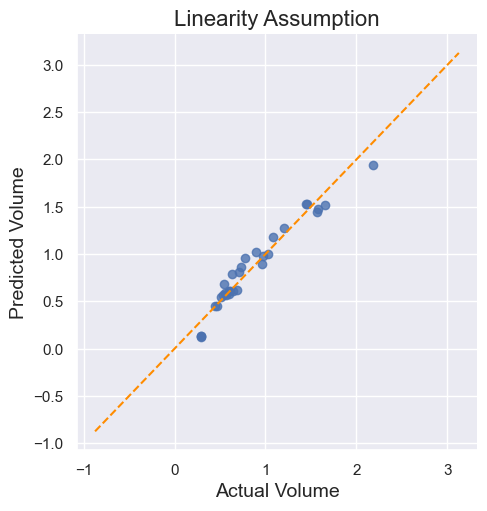

there is linear relationship between our independent and dependent variables.


In [34]:
# Plotting the observed vs predited values
sns.lmplot(x='Volume', y='volume_pred', data=df, fit_reg=False)

# Plotting the diagonal line
line_coords = np.arange(df[['Volume', 'volume_pred']].min().min()-1,
                        df[['Volume', 'volume_pred']].max().max()+1)
plt.plot(line_coords, line_coords,  # X and y points
         color='darkorange', linestyle='--')

plt.ylabel('Predicted Volume', fontsize = 14)
plt.xlabel('Actual Volume', fontsize = 14)
plt.title('Linearity Assumption', fontsize = 16)
plt.show()
print("there is linear relationship between our independent and dependent variables.")

### Normality

p-value from the test Anderson-Darling test below 0.05 generally means non-normal: 0.6742887060898438
Residuals are normally distributed


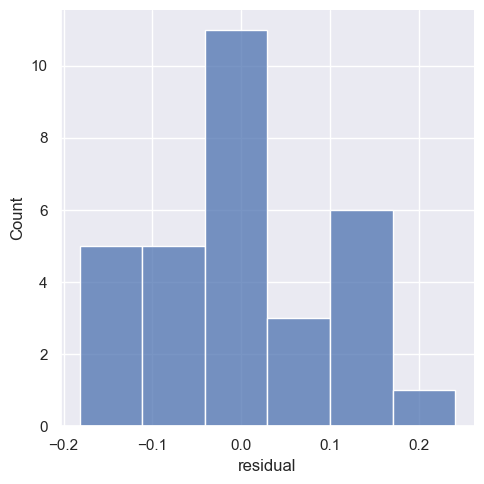

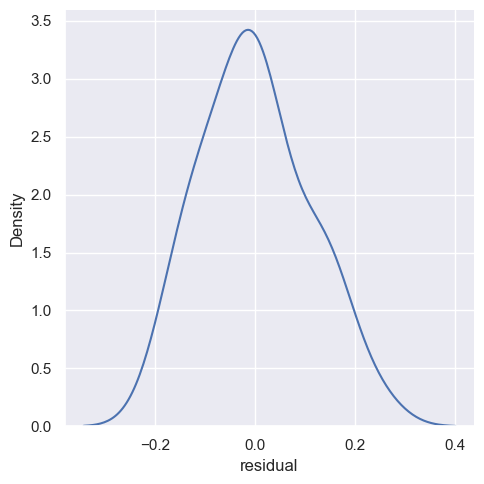

In [35]:
from statsmodels.stats.diagnostic import normal_ad

# Performing the test on the residuals
p_value = normal_ad(df['residual'])[1]
print('p-value from the test Anderson-Darling test below 0.05 generally means non-normal:', p_value)

# Plotting the residuals distribution
sns.displot(df['residual'])
sns.displot(df['residual'], kind='kde')

# Reporting the normality of the residuals
if p_value < 0.05:
    print('Residuals are not normally distributed')
else:
    print('Residuals are normally distributed')

### Multicollinearity

Pearson correlation coefficient matrix of each variables:
           Volume     Girth    Height
Volume  1.000000  0.966998  0.598198
Girth   0.966998  1.000000  0.519539
Height  0.598198  0.519539  1.000000


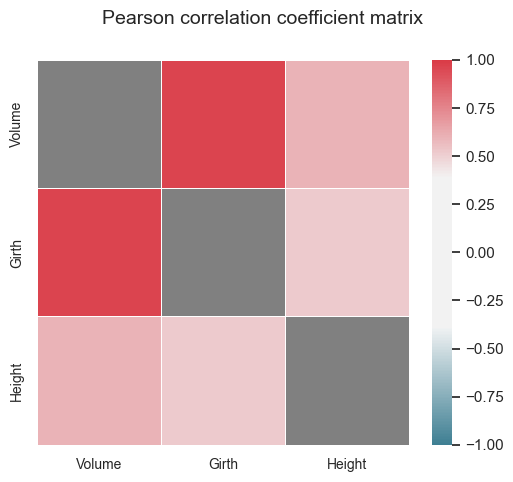

In [37]:
corr = df[['Volume','Girth', 'Height']].corr()
print('Pearson correlation coefficient matrix of each variables:\n', corr)

# Generate a mask for the diagonal cell
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, val=True)

# Initialize matplotlib figure
fig, ax = plt.subplots(figsize=(6, 5))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True, sep=100)
cmap.set_bad('grey')

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0, linewidths=.5)
fig.suptitle('Pearson correlation coefficient matrix', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=10)
# fig.tight_layout()

### Auto-Correlation

In [38]:
from statsmodels.stats.stattools import durbin_watson

durbinWatson = durbin_watson(df['residual'])

print('Durbin-Watson:', durbinWatson)
if durbinWatson < 1.5:
    print('Signs of positive autocorrelation', '\n')
    print('Assumption not satisfied')
elif durbinWatson > 2.5:
    print('Signs of negative autocorrelation', '\n')
    print('Assumption not satisfied')
else:
    print('Little to no autocorrelation', '\n')
    print('Assumption satisfied')

Durbin-Watson: 1.2583571344933628
Signs of positive autocorrelation 

Assumption not satisfied


### Homoscedasticity

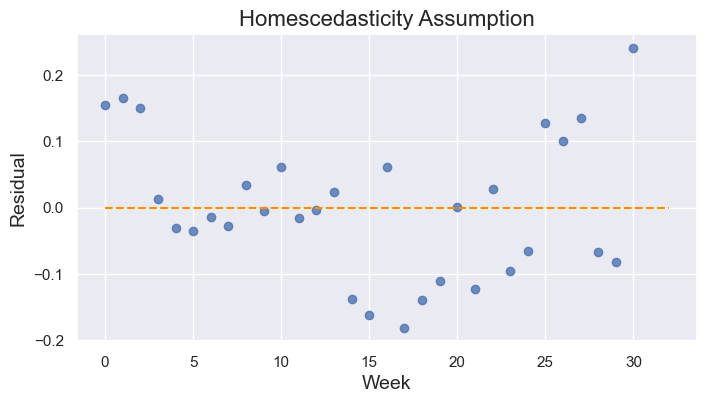

In [39]:
plt.subplots(figsize=(8, 4))
plt.scatter(x=df.index, y=df.residual, alpha=0.8)
plt.plot(np.repeat(0, len(df.index)+2), color='darkorange', linestyle='--')

plt.ylabel('Residual', fontsize=14)
plt.xlabel('Week', fontsize=14)
plt.title('Homescedasticity Assumption', fontsize=16)
plt.show()

## Code refs

https://www.geo.fu-berlin.de/en/v/soga-py/Advanced-statistics/Multivariate-Approaches/Multiple-linear-regression/MLR-simple-example/index.html

https://ethanweed.github.io/pythonbook/05.04-regression.html



https://medium.com/swlh/multi-linear-regression-using-python-44bd0d10082d

https://www.geo.fu-berlin.de/en/v/soga-py/Advanced-statistics/Multivariate-Approaches/Multiple-linear-regression/MLR-simple-example/index.html
https://medium.com/analytics-vidhya/multiple-linear-regression-from-scratch-using-only-numpy-98fc010a1926